# <p style="font-family: Cambria; text-align: center; font-size: 44px;">III. PRESCRIPTIVE ANALYSIS (Q16-Q30)</p>


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("Team2_PythonPioneers_Cardiac_Cleaned_Data.csv")
print(df.shape)

(2008, 210)


In [5]:
# Show very small p-values as "<0.001"
def p_text(p):
    if p < 0.001:
        return "<0.001"
    return round(float(p), 3)

# Chi-square test: is the outcome rate different between groups?
def chi_square(group_col, outcome_col, data):
    table = pd.crosstab(data[group_col], data[outcome_col])
    chi2, p, dof, expected = stats.chi2_contingency(table)
    return p_text(p)

# Fisher test for two groups: returns odds ratio and p-value
def fisher(flag_col, outcome_col, data):
    table = pd.crosstab(data[flag_col], data[outcome_col])
    odds_ratio, p = stats.fisher_exact(table.values)
    return round(float(odds_ratio), 2), p_text(p)

# Mann-Whitney test: are the values different in patients who died vs survived?
def mann_whitney(value_col, outcome_col, data):
    died = data.loc[data[outcome_col] == 1, value_col].dropna()
    survived = data.loc[data[outcome_col] == 0, value_col].dropna()
    u, p = stats.mannwhitneyu(died, survived)
    return round(float(died.median()), 2), round(float(survived.median()), 2), p_text(p)

# 1 = patient died in hospital
df["in_hospital_death"] = (df["outcome_during_hospitalization"] == "Dead").astype(int)

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q16. Acute kidney failure vs CKD – Do patients with acute kidney failure during hospitalization have different length of stay and mortality outcomes compared with patients who have chronic kidney disease alone, both conditions, or neither?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>acute_renal_failure, moderate_to_severe_chronic_kidney_disease, dischargeday, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Kidney dysfunction is an important complication in patients with heart failure because the heart and kidneys strongly influence each other. Chronic kidney disease represents long-standing kidney impairment, while acute kidney failure represents a sudden deterioration during the patient's illness. We divide patients into four groups: neither condition, CKD only, acute kidney failure only, and both conditions. We then compare length of hospital stay and 28-day mortality across these groups to determine whether acute kidney failure, either alone or combined with CKD, identifies patients with a greater observed hospital and mortality burden.</b></i></p>

,Patients,Avg_Length_of_Stay,Median_Length_of_Stay,Deaths,Mortality_Rate,Mortality_Rate_%
Kidney_Group,,,,,,
Acute Failure Only,4,8.25,9.5,1,0.25,25.00
Both,3,5.67,6.0,1,0.33,33.33
CKD Only,471,10.96,9.0,18,0.04,3.82
Neither,1530,8.96,7.0,17,0.01,1.11


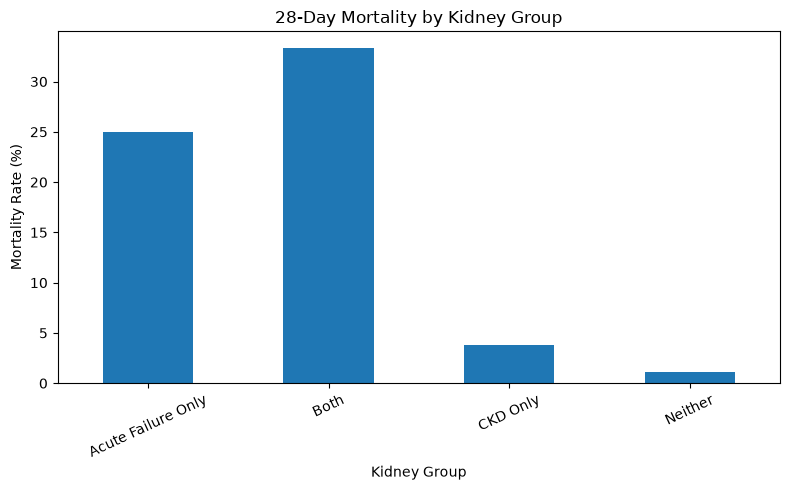

In [6]:
# Q16: Acute kidney failure vs CKD

q16 = df[
    [
        "inpatient_number",
        "moderate_to_severe_chronic_kidney_disease",
        "acute_renal_failure",
        "dischargeday",
        "death_within_28_days"
    ]
].copy()

# Convert kidney indicators to numeric
q16["CKD"] = pd.to_numeric(
    q16["moderate_to_severe_chronic_kidney_disease"],
    errors="coerce"
).fillna(0)

q16["AKI"] = pd.to_numeric(
    q16["acute_renal_failure"],
    errors="coerce"
).fillna(0)

# Create kidney groups
q16["Kidney_Group"] = np.select(
    [
        (q16["CKD"] == 0) & (q16["AKI"] == 0),
        (q16["CKD"] > 0) & (q16["AKI"] == 0),
        (q16["CKD"] == 0) & (q16["AKI"] > 0),
        (q16["CKD"] > 0) & (q16["AKI"] > 0)
    ],
    [
        "Neither",
        "CKD Only",
        "Acute Failure Only",
        "Both"
    ],
    default="Unknown"
)

q16_summary = q16.groupby("Kidney_Group").agg(
    Patients=("inpatient_number", "count"),
    Avg_Length_of_Stay=("dischargeday", "mean"),
    Median_Length_of_Stay=("dischargeday", "median"),
    Deaths=("death_within_28_days", "sum"),
    Mortality_Rate=("death_within_28_days", "mean")
)

q16_summary["Mortality_Rate_%"] = (
    q16_summary["Mortality_Rate"] * 100
).round(2)

display(q16_summary.round(2))

# Chart
q16_summary["Mortality_Rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("28-Day Mortality by Kidney Group")
plt.xlabel("Kidney Group")
plt.ylabel("Mortality Rate (%)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with COPD and/or type II respiratory failure had clearly higher CO₂ levels, with an average of 39.56 compared with 34.73 in patients without these respiratory conditions. Oxygen therapy was also more common: 99.05% of the respiratory-disease group received oxygen therapy compared with 93.67% of patients without respiratory disease. However, 6-month readmission was not higher in the respiratory-disease group; it was 37.22% compared with 38.73% in patients without respiratory disease.<br><b>What this means:</b> COPD and type II respiratory failure identify patients with greater respiratory burden, especially higher CO₂ and greater oxygen use, but in this dataset they do not appear to identify a group with higher 6-month readmission based on the descriptive rates alone.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q17. Respiratory disease – Are COPD and type II respiratory failure associated with higher CO₂ levels, greater oxygen requirements and higher readmission rates?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>chronic_obstructive_pulmonary_disease, type_ii_respiratory_failure, partial_pressure_of_carbon_dioxide, oxygen_inhalation, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Heart failure and respiratory disease can place additional stress on each other. COPD can reduce effective ventilation, while type II respiratory failure is characterized by difficulty removing carbon dioxide from the body. Patients with these respiratory conditions may therefore have higher CO₂ levels, greater need for supplemental oxygen and more complicated recovery after discharge. We compare patients with COPD and/or type II respiratory failure with patients without these conditions to determine whether respiratory disease is associated with greater physiological burden and higher observed readmission.</b></i></p>

In [7]:
# Q17: COPD / Type II respiratory failure

q17 = df[
    [
        "inpatient_number",
        "chronic_obstructive_pulmonary_disease",
        "type_ii_respiratory_failure",
        "partial_pressure_of_carbon_dioxide",
        "oxygen_inhalation",
        "re_admission_within_6_months"
    ]
].copy()

copd = pd.to_numeric(
    q17["chronic_obstructive_pulmonary_disease"],
    errors="coerce"
).fillna(0)

resp_failure = pd.to_numeric(
    q17["type_ii_respiratory_failure"],
    errors="coerce"
).fillna(0)

q17["Respiratory_Group"] = np.where(
    (copd > 0) | (resp_failure > 0),
    "COPD / Type II Respiratory Failure",
    "No Respiratory Disease"
)

q17_summary = q17.groupby("Respiratory_Group").agg(
    Patients=("inpatient_number", "count"),
    Avg_CO2=("partial_pressure_of_carbon_dioxide", "mean"),
    Median_CO2=("partial_pressure_of_carbon_dioxide", "median"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q17_summary["Readmission_Rate_%"] = (
    q17_summary["Readmission_Rate"] * 100
).round(2)

display(q17_summary.round(2))

# Oxygen requirement
oxygen_table = pd.crosstab(
    q17["Respiratory_Group"],
    q17["oxygen_inhalation"],
    normalize="index"
) * 100

print("Oxygen Requirement (%)")
display(oxygen_table.round(2))

,Patients,Avg_CO2,Median_CO2,Readmission_Rate,Readmission_Rate_%
Respiratory_Group,,,,,
COPD / Type II Respiratory Failure,317,39.56,37.0,0.37,37.22
No Respiratory Disease,1691,34.73,34.0,0.39,38.73


Oxygen Requirement (%)


oxygen_inhalation,AmbientAir,OxygenTherapy
Respiratory_Group,,
COPD / Type II Respiratory Failure,0.95,99.05
No Respiratory Disease,6.33,93.67


In [8]:
df["respiratory_support"].value_counts(dropna=False)

respiratory_support
NaN     1966
IMV       25
NIMV      17
Name: count, dtype: int64

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with COPD and/or type II respiratory failure had clearly higher CO₂ levels, with an average of 39.56 compared with 34.73 in patients without these respiratory conditions. Oxygen therapy was also more common: 99.05% of the respiratory-disease group received oxygen therapy compared with 93.67% of patients without respiratory disease. However, 6-month readmission was not higher in the respiratory-disease group; it was 37.22% compared with 38.73% in patients without respiratory disease.<br><b>What this means:</b> COPD and type II respiratory failure identify patients with greater respiratory burden, especially higher CO₂ and greater oxygen use, but in this dataset they do not appear to identify a group with higher 6-month readmission based on the descriptive rates alone.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q18. Mechanical ventilation – How do patients who required mechanical ventilation differ from those who did not in NYHA class, BNP, troponin levels and mortality outcomes?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>respiratory_support, nyha_cardiac_function_classification, brain_natriuretic_peptide, high_sensitivity_troponin, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients requiring mechanical ventilation or respiratory support may represent a more severely ill subgroup of heart-failure patients. NYHA class describes functional cardiac limitation, BNP reflects cardiac wall stress, and high-sensitivity troponin reflects myocardial injury. By comparing these measures and mortality between patients who required respiratory support and those who did not, we can determine whether the support group shows a more severe cardiac profile and poorer observed outcomes. The respiratory_support field should only be described specifically as mechanical ventilation if its coding confirms that meaning.</b></i></p>

In [9]:
# Q18: Mechanical ventilation / respiratory support

q18 = df[
    [
        "inpatient_number",
        "respiratory_support",
        "nyha_cardiac_function_classification",
        "brain_natriuretic_peptide",
        "high_sensitivity_troponin",
        "death_within_28_days"
    ]
].copy()

# IMV = invasive mechanical ventilation; NIMV = non-invasive mechanical ventilation
q18["Ventilation_Group"] = np.where(
    q18["respiratory_support"].isin(["IMV", "NIMV"]),
    "Mechanical Ventilation",
    "No Recorded Ventilation"
)

q18_summary = q18.groupby("Ventilation_Group").agg(
    Patients=("inpatient_number", "count"),
    Avg_BNP=("brain_natriuretic_peptide", "mean"),
    Median_BNP=("brain_natriuretic_peptide", "median"),
    Avg_Troponin=("high_sensitivity_troponin", "mean"),
    Median_Troponin=("high_sensitivity_troponin", "median"),
    Mortality_Rate=("death_within_28_days", "mean")
)

q18_summary["Mortality_Rate_%"] = (q18_summary["Mortality_Rate"] * 100).round(2)
display(q18_summary.round(2))

nyha_table = pd.crosstab(
    q18["Ventilation_Group"],
    q18["nyha_cardiac_function_classification"],
    normalize="index"
) * 100

print("NYHA Distribution (%)")
display(nyha_table.round(2))


,Patients,Avg_BNP,Median_BNP,Avg_Troponin,Median_Troponin,Mortality_Rate,Mortality_Rate_%
Ventilation_Group,,,,,,,
Mechanical Ventilation,42,1623.99,1169.52,2159.31,201.5,0.17,16.67
No Recorded Ventilation,1966,1273.15,744.38,239.75,54.0,0.02,1.53


NYHA Distribution (%)


nyha_cardiac_function_classification,2,3,4
Ventilation_Group,,,
Mechanical Ventilation,2.38,19.05,78.57
No Recorded Ventilation,17.90,52.44,29.65



<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>
<p style="font-family: Cambria; font-size: 16px;"><i><b>
There were {vp} patients with recorded mechanical ventilation (IMV or NIMV), compared with {np_} patients with no recorded ventilation.
Average BNP was {vb:.2f} in the ventilation group compared with {nb:.2f} in the no-recorded-ventilation group, while average troponin was {vt:.2f} compared with {nt:.2f}.
The 28-day mortality rate was {vm:.2f}% in the ventilation group compared with {nm:.2f}% in the no-recorded-ventilation group.
<br><b>What this means:</b> Patients requiring IMV or NIMV can be compared with patients without recorded ventilation to assess whether respiratory support identifies a subgroup with greater cardiac severity and poorer observed outcomes. Because ventilation is generally used in more severely ill patients, this is an association with disease severity and should not be interpreted as evidence that ventilation caused the outcome.
</b></i></p>



<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q19. Medication burden and comorbidity – Are patients with both high comorbidity burden and high medication counts more likely to experience adverse outcomes than patients without this combined profile?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>cci_score, total_drugs, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The Charlson Comorbidity Index summarizes the burden of multiple chronic diseases, while total medication count provides an indication of treatment complexity. Patients who have both a high comorbidity burden and a high medication count may represent a particularly complex clinical group. We create a combined high-burden group and compare its mortality and readmission outcomes with those of other patients. This helps determine whether the combination of disease burden and medication burden identifies patients with poorer observed outcomes who may require more coordinated follow-up.</b></i></p>

In [10]:
# Q19: High comorbidity + high medication burden

q19 = df[
    [
        "inpatient_number",
        "cci_score",
        "total_drugs",
        "death_within_28_days",
        "re_admission_within_6_months"
    ]
].copy()

# High comorbidity = CCI 5+
q19["High_Comorbidity"] = (
    pd.to_numeric(
        q19["cci_score"],
        errors="coerce"
    ) >= 5
)

# High medication burden = upper 25%
medication_cutoff = q19["total_drugs"].quantile(0.75)

q19["High_Medication"] = (
    q19["total_drugs"] >= medication_cutoff
)

q19["Combined_Profile"] = np.where(
    q19["High_Comorbidity"] &
    q19["High_Medication"],
    "High Comorbidity + High Medication",
    "Other Patients"
)

q19_summary = q19.groupby("Combined_Profile").agg(
    Patients=("inpatient_number", "count"),
    Avg_CCI=("cci_score", "mean"),
    Avg_Medications=("total_drugs", "mean"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q19_summary["Mortality_Rate_%"] = (
    q19_summary["Mortality_Rate"] * 100
).round(2)

q19_summary["Readmission_Rate_%"] = (
    q19_summary["Readmission_Rate"] * 100
).round(2)

print("High medication cutoff:", medication_cutoff)

display(q19_summary.round(2))

High medication cutoff: 9.0


,Patients,Avg_CCI,Avg_Medications,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Combined_Profile,,,,,,,
High Comorbidity + High Medication,10,5.10,10.20,0.10,0.60,10.0,60.00
Other Patients,1998,1.85,7.64,0.02,0.38,1.8,38.39


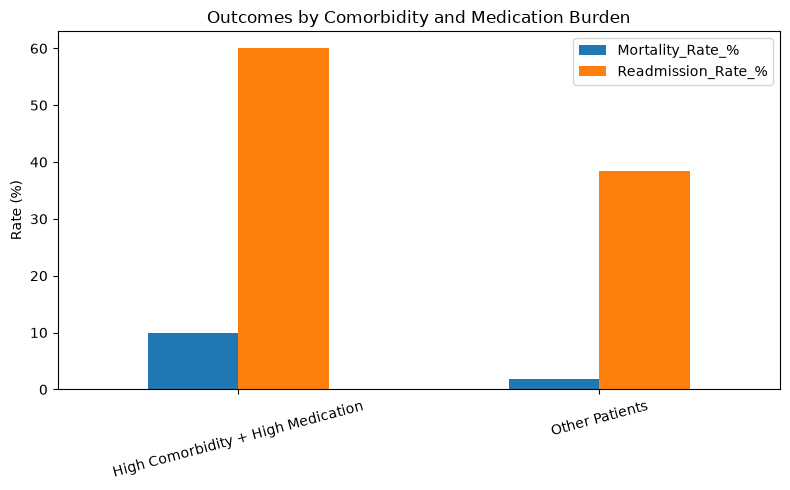

In [11]:
q19_summary[
    ["Mortality_Rate_%", "Readmission_Rate_%"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Outcomes by Comorbidity and Medication Burden")
plt.ylabel("Rate (%)")
plt.xlabel("")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients with both high comorbidity burden and high medication use had substantially worse observed outcomes. Using 9 medications as the high-medication cutoff, this combined high-burden group had an average CCI score of 5.10 and 10.20 medications. Their 28-day mortality was 10.0%, compared with 1.8% among other patients, while 6-month readmission was 60.0% compared with 38.39%. However, only 10 patients met the combined high-burden definition, so these percentages should be interpreted cautiously.<br><b>What this means:</b> patients with both very high comorbidity and medication burden may represent an especially complex high-risk group that could benefit from closer medication review and follow-up, but the small group size means this finding should be validated before being used as a clinical rule.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q20. Guideline medication count – Is the number of guideline-directed heart-failure medications received at discharge associated with differences in readmission and mortality outcomes?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>Metoprolol Succinate Sustained-release tablet, metoprolol tartrate injection, Benazepril hydrochloride tablet, Valsartan Dispersible tablet, Spironolactone tablet, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>The cleaned dataset contains prescription indicators that can be grouped into beta-blocker, ACE inhibitor/ARB and spironolactone categories. We count how many of these three medication groups are recorded for each patient and compare mortality and readmission across patients receiving zero, one, two or three groups. This allows us to examine whether the number of recorded heart-failure medication groups is associated with differences in observed outcomes. Because this is observational data, any relationship should be interpreted as an association and not as proof that receiving more or fewer medications caused the outcome.</b></i></p>

In [12]:
# Q20: Guideline-directed medication count

q20 = df.copy()

beta_cols = [
    "Metoprolol Succinate Sustained-release tablet",
    "metoprolol tartrate injection"
]

ace_arb_cols = [
    "Benazepril hydrochloride tablet",
    "Valsartan Dispersible tablet"
]

spironolactone_col = "Spironolactone tablet"

# Beta-blocker
q20["Beta_Blocker"] = (
    q20[beta_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

# ACE inhibitor / ARB
q20["ACE_ARB"] = (
    q20[ace_arb_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

# Spironolactone
q20["Spironolactone"] = (
    pd.to_numeric(
        q20[spironolactone_col],
        errors="coerce"
    )
    .fillna(0)
    .gt(0)
    .astype(int)
)

# Number of therapy groups: 0–3
q20["Guideline_Med_Count"] = (
    q20["Beta_Blocker"] +
    q20["ACE_ARB"] +
    q20["Spironolactone"]
)

q20_summary = q20.groupby(
    "Guideline_Med_Count"
).agg(
    Patients=("inpatient_number", "count"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q20_summary["Mortality_Rate_%"] = (
    q20_summary["Mortality_Rate"] * 100
).round(2)

q20_summary["Readmission_Rate_%"] = (
    q20_summary["Readmission_Rate"] * 100
).round(2)

display(q20_summary)

,Patients,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Guideline_Med_Count,,,,,
0,120,0.100000,0.250000,10.00,25.00
1,800,0.022500,0.375000,2.25,37.50
2,699,0.010014,0.427754,1.00,42.78
3,389,0.000000,0.370180,0.00,37.02


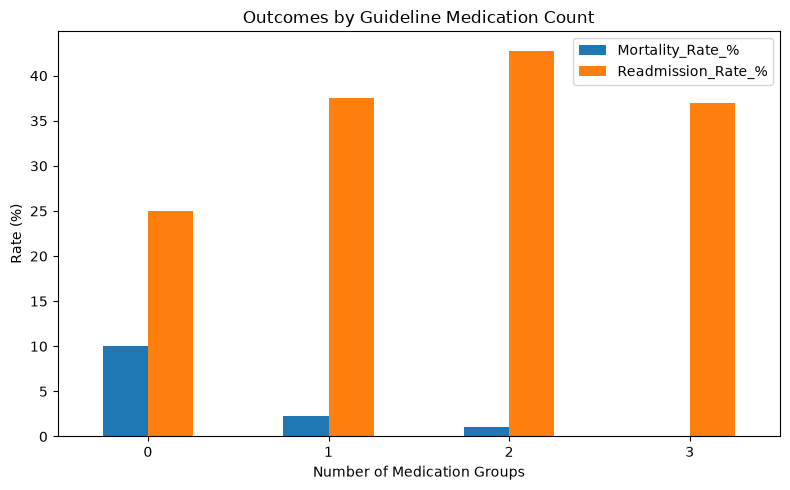

In [13]:
q20_summary[
    ["Mortality_Rate_%", "Readmission_Rate_%"]
].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Outcomes by Guideline Medication Count")
plt.xlabel("Number of Medication Groups")
plt.ylabel("Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>28-day mortality decreased steadily as the number of recorded heart-failure medication groups increased: mortality was 10.0% with no medication groups, 2.25% with one group, 1.0% with two groups and 0% with all three groups. The readmission pattern was different: 6-month readmission was 25.0% with no groups, 37.5% with one, 42.78% with two and 37.02% with three. Therefore, the strongest descriptive pattern is seen for mortality rather than readmission.<br><b>What this means:</b> patients with more recorded heart-failure medication groups had lower observed 28-day mortality, but this is an observational association and does not prove that increasing medication count caused lower mortality. Differences in disease severity, eligibility for treatment and prescribing patterns may also explain the result.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q21. Inotrope use – Do patients receiving inotropic medications such as milrinone, dobutamine or deslanoside have greater markers of disease severity and worse outcomes than patients who do not receive these medications?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>Milrinone injection, Dobutamine hydrochloride injection, Deslanoside injection, nyha_cardiac_function_classification, lvef, brain_natriuretic_peptide, high_sensitivity_troponin, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Inotropic medications such as milrinone, dobutamine and deslanoside may be used in patients with more severe cardiac dysfunction. We therefore compare patients with recorded inotrope use against those without recorded use using NYHA class, LVEF, BNP, troponin, mortality and readmission. If inotrope users show more severe cardiac markers and poorer outcomes, this would identify them as a higher-severity subgroup. It would not demonstrate that the medications caused the poorer outcomes because sicker patients may be more likely to receive these drugs.</b></i></p>

In [14]:
# Q21: Inotrope use

q21 = df.copy()

inotrope_cols = [
    "Milrinone injection",
    "Dobutamine hydrochloride injection",
    "Deslanoside injection"
]

q21["Inotrope_Use"] = (
    q21[inotrope_cols]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .gt(0)
    .any(axis=1)
    .astype(int)
)

q21["Inotrope_Group"] = q21[
    "Inotrope_Use"
].map({
    0: "No Inotrope",
    1: "Inotrope"
})

q21_summary = q21.groupby(
    "Inotrope_Group"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_LVEF=("lvef", "mean"),
    Avg_BNP=("brain_natriuretic_peptide", "mean"),
    Avg_Troponin=("high_sensitivity_troponin", "mean"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q21_summary["Mortality_Rate_%"] = (
    q21_summary["Mortality_Rate"] * 100
).round(2)

q21_summary["Readmission_Rate_%"] = (
    q21_summary["Readmission_Rate"] * 100
).round(2)

display(q21_summary.round(2))

,Patients,Avg_LVEF,Avg_BNP,Avg_Troponin,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Inotrope_Group,,,,,,,,
Inotrope,1249,48.44,1589.71,379.57,0.02,0.41,2.16,41.39
No Inotrope,759,54.28,762.89,114.72,0.01,0.34,1.32,33.73


In [15]:
nyha_inotrope = pd.crosstab(
    q21["Inotrope_Group"],
    q21["nyha_cardiac_function_classification"],
    normalize="index"
) * 100

print("NYHA Distribution (%)")
display(nyha_inotrope.round(2))

NYHA Distribution (%)


nyha_cardiac_function_classification,2,3,4
Inotrope_Group,,,
Inotrope,14.09,47.80,38.11
No Inotrope,23.32,58.23,18.45


<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients receiving inotropes showed a substantially more severe cardiac profile. Their average LVEF was lower at 48.44% compared with 54.28% in patients without inotropes, while average BNP was more than twice as high (1,589.71 vs 762.89) and average troponin was more than three times as high (379.57 vs 114.72). NYHA class IV was also much more common among inotrope users (38.11% vs 18.45%). Their 28-day mortality was 2.16% compared with 1.32%, and 6-month readmission was 41.39% compared with 33.73%.<br><b>What this means:</b> inotrope use identifies a group with greater cardiac dysfunction, biomarker elevation and poorer observed outcomes. This should mainly be interpreted as a marker of disease severity rather than evidence that inotropes themselves caused the worse outcomes.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q22. Blood pressure and shock index – Are lower systolic blood pressure and higher admission shock index associated with increased risk of death?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>pulse, systolic_blood_pressure, death_within_28_days</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Derived variable:</b> <code>Shock Index = pulse / systolic_blood_pressure</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Blood pressure and heart rate provide information about cardiovascular stability. A patient with a relatively high pulse and low systolic blood pressure will have a higher shock index, which can indicate greater hemodynamic stress. We calculate shock index from the available pulse and systolic blood-pressure measurements and compare systolic pressure and shock index between patients who survived and those who died. We also divide shock index into data-based groups to examine whether observed mortality rises as the shock index increases.</b></i></p>

In [16]:
# Q22: Blood pressure and shock index

q22 = df[
    [
        "inpatient_number",
        "pulse",
        "systolic_blood_pressure",
        "death_within_28_days"
    ]
].copy()

q22["pulse"] = pd.to_numeric(
    q22["pulse"],
    errors="coerce"
)

q22["systolic_blood_pressure"] = pd.to_numeric(
    q22["systolic_blood_pressure"],
    errors="coerce"
)

# Remove impossible zero/negative BP values
q22.loc[
    q22["systolic_blood_pressure"] <= 0,
    "systolic_blood_pressure"
] = np.nan

# Calculate shock index
q22["Shock_Index"] = (
    q22["pulse"] /
    q22["systolic_blood_pressure"]
)

# Compare patients by mortality outcome
q22_summary = q22.groupby(
    "death_within_28_days"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_Systolic_BP=("systolic_blood_pressure", "mean"),
    Median_Systolic_BP=("systolic_blood_pressure", "median"),
    Avg_Shock_Index=("Shock_Index", "mean"),
    Median_Shock_Index=("Shock_Index", "median")
)

display(q22_summary.round(3))

,Patients,Avg_Systolic_BP,Median_Systolic_BP,Avg_Shock_Index,Median_Shock_Index
death_within_28_days,,,,,
0,1971,131.378,130.0,0.668,0.636
1,37,126.417,127.0,0.734,0.689


In [17]:
q22["Shock_Index_Group"] = pd.qcut(
    q22["Shock_Index"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ],
    duplicates="drop"
)

shock_summary = q22.groupby(
    "Shock_Index_Group",
    observed=False
).agg(
    Patients=("inpatient_number", "count"),
    Deaths=("death_within_28_days", "sum"),
    Mortality_Rate=("death_within_28_days", "mean")
)

shock_summary["Mortality_Rate_%"] = (
    shock_summary["Mortality_Rate"] * 100
).round(2)

display(shock_summary)

,Patients,Deaths,Mortality_Rate,Mortality_Rate_%
Shock_Index_Group,,,,
Q1 - Lowest,502,7,0.013944,1.39
Q2,500,6,0.012000,1.20
Q3,500,11,0.022000,2.20
Q4 - Highest,501,12,0.023952,2.40


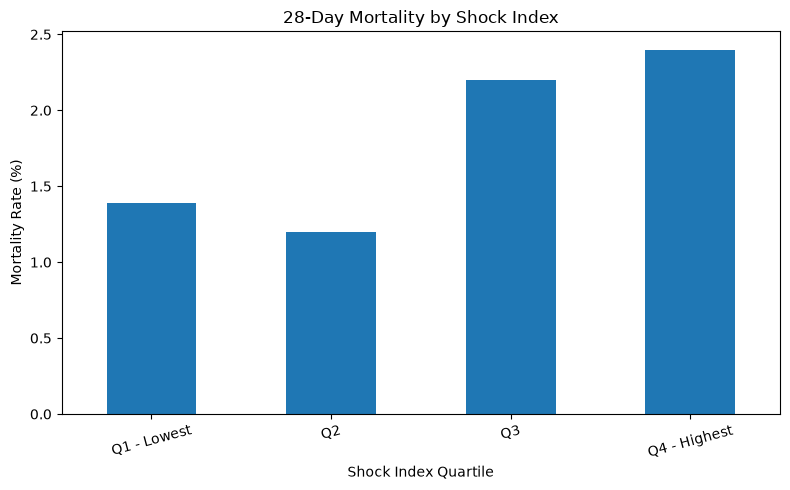

In [18]:
shock_summary["Mortality_Rate_%"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("28-Day Mortality by Shock Index")
plt.xlabel("Shock Index Quartile")
plt.ylabel("Mortality Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Patients who died within 28 days had lower average systolic blood pressure and a higher shock index than survivors. Average systolic pressure was 126.42 mmHg among patients who died compared with 131.38 mmHg among survivors, while average shock index was 0.734 compared with 0.668. The quartile analysis also shows a general increase in mortality at higher shock index levels: mortality was 1.39% in Q1, 1.20% in Q2, 2.20% in Q3 and 2.40% in the highest quartile.<br><b>What this means:</b> the combination of a faster pulse relative to systolic blood pressure may help identify patients with greater hemodynamic risk. The highest shock-index quartile had approximately twice the observed mortality of Q2, although statistical testing is needed before concluding that the difference is significant.</b></i></p>

<p style="font-family: Cambria; font-size: 20px; color:red;"><b>Q23. BMI and albumin – Is lower BMI associated with lower albumin levels and worse patient outcomes, particularly among underweight patients?</b></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Columns used:</b> <code>bmi, bmi_category, albumin, death_within_28_days, re_admission_within_6_months</code></p>

<p style="font-family: Cambria; font-size: 16px;"><b>Reasoning</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>BMI provides a measure of body size, while albumin can provide information related to nutritional and overall health status. In patients with heart failure, a low BMI together with lower albumin may identify a subgroup with greater physiological vulnerability. We compare albumin, mortality and readmission across BMI categories and then specifically compare underweight patients with the remaining BMI groups. We also examine the relationship between BMI and albumin to determine whether lower body mass is associated with lower albumin and poorer observed outcomes in this dataset.</b></i></p>

In [19]:
# Q23: BMI, albumin and outcomes

q23 = df[
    [
        "inpatient_number",
        "bmi",
        "bmi_category",
        "albumin",
        "death_within_28_days",
        "re_admission_within_6_months"
    ]
].copy()

q23_summary = q23.groupby(
    "bmi_category"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_BMI=("bmi", "mean"),
    Avg_Albumin=("albumin", "mean"),
    Median_Albumin=("albumin", "median"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

q23_summary["Mortality_Rate_%"] = (
    q23_summary["Mortality_Rate"] * 100
).round(2)

q23_summary["Readmission_Rate_%"] = (
    q23_summary["Readmission_Rate"] * 100
).round(2)

display(q23_summary.round(2))

,Patients,Avg_BMI,Avg_Albumin,Median_Albumin,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
bmi_category,,,,,,,,
Normal,1184,21.36,36.53,36.7,0.02,0.37,1.86,37.42
Obese,66,32.06,35.94,37.4,0.00,0.38,0.00,37.88
Overweight,243,26.82,37.26,37.3,0.01,0.40,1.23,39.51
Underweight,507,17.09,36.24,36.4,0.02,0.41,2.37,41.03


In [20]:
correlation = q23[
    ["bmi", "albumin"]
].corr()

print("BMI and Albumin Correlation:")
display(correlation.round(3))

BMI and Albumin Correlation:


,bmi,albumin
bmi,1.000,0.054
albumin,0.054,1.000


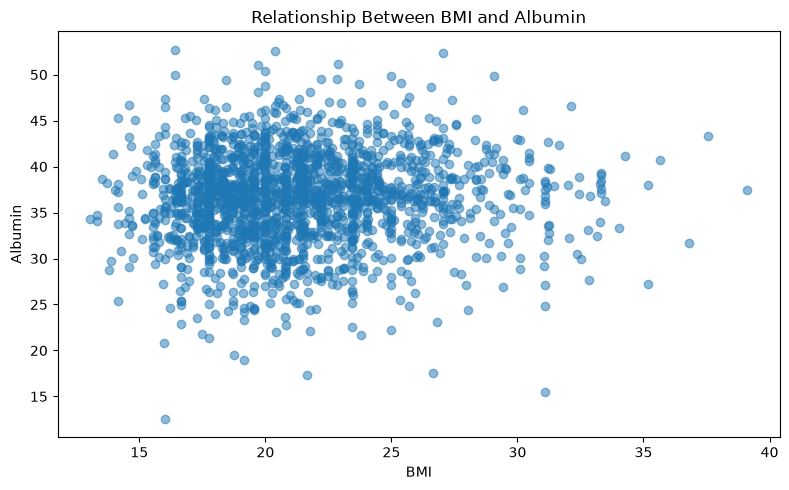

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    q23["bmi"],
    q23["albumin"],
    alpha=0.5
)

plt.title("Relationship Between BMI and Albumin")
plt.xlabel("BMI")
plt.ylabel("Albumin")
plt.tight_layout()
plt.show()

In [22]:
q23["Weight_Group"] = np.where(
    q23["bmi_category"] == "Underweight",
    "Underweight",
    "Other BMI Categories"
)

underweight_summary = q23.groupby(
    "Weight_Group"
).agg(
    Patients=("inpatient_number", "count"),
    Avg_Albumin=("albumin", "mean"),
    Mortality_Rate=("death_within_28_days", "mean"),
    Readmission_Rate=("re_admission_within_6_months", "mean")
)

underweight_summary["Mortality_Rate_%"] = (
    underweight_summary["Mortality_Rate"] * 100
).round(2)

underweight_summary["Readmission_Rate_%"] = (
    underweight_summary["Readmission_Rate"] * 100
).round(2)

display(underweight_summary.round(2))

,Patients,Avg_Albumin,Mortality_Rate,Readmission_Rate,Mortality_Rate_%,Readmission_Rate_%
Weight_Group,,,,,,
Other BMI Categories,1501,36.63,0.02,0.38,1.67,37.64
Underweight,507,36.24,0.02,0.41,2.37,41.03


<p style="font-family: Cambria; font-size: 16px;"><b>Insight</b></p>

<p style="font-family: Cambria; font-size: 16px;"><i><b>Underweight patients had an average albumin level of 36.24 compared with 36.63 among all other BMI categories, but the overall correlation between BMI and albumin was only 0.054, showing almost no linear relationship. Underweight patients nevertheless had the highest observed 28-day mortality among the main BMI groups at 2.37%, compared with 1.86% in normal-weight patients, 1.23% in overweight patients and 0% in the small obese group. Their 6-month readmission rate was also higher at 41.03% compared with 37.64% among all other BMI categories combined.<br><b>What this means:</b> underweight patients show somewhat poorer observed outcomes, but lower albumin does not strongly explain this pattern because BMI and albumin are only very weakly correlated in this dataset. BMI may therefore be more useful as part of a broader risk profile rather than as a stand-alone nutritional risk marker.</b></i></p>